# Adaptive Gradient Methods: GD, Adagrad, RMSProp, Momentum, and Adam

This notebook compares five popular optimization algorithms on the Beale and Rosenbrock test functions. The learning objectives are:

- Understand how **adaptive methods** modify the learning rate per coordinate to handle varying curvature.
- See the practical differences between gradient descent, heavy ball (momentum), Adagrad, RMSProp, and Adam on non-convex landscapes.
- Investigate the effect of step size, initialization, and backtracking line search on convergence and success rate.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
from sklearn.linear_model import LinearRegression

from matplotlib.colors import LogNorm


plt.rcParams['font.family'] = ['sans-serif']
#plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'svg'

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# This allows multiple outputs from a single jupyter notebook cell:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Algorithm Overview

Let $g_t = \nabla f(x_t)$ denote the gradient at iteration $t$.

**Gradient Descent:** $\; x_{t+1} = x_t - \alpha\, g_t$.

**Heavy Ball (Momentum):** $\; x_{t+1} = x_t - \alpha\, g_t + \beta (x_t - x_{t-1})$.

**Adagrad:** Accumulates all past squared gradients $G_t = \sum_{k=1}^{t} g_k \odot g_k$ and sets
$$x_{t+1} = x_t - \frac{\alpha}{\sqrt{G_t} + \epsilon}\odot g_t.$$
This effectively gives coordinates with large historical gradients a smaller step size.

**RMSProp:** Replaces the sum in Adagrad with an exponential moving average:
$$v_t = \gamma\, v_{t-1} + (1-\gamma)\, g_t^2, \qquad x_{t+1} = x_t - \frac{\alpha}{\sqrt{v_t}+\epsilon}\odot g_t.$$

**Adam:** Combines momentum with RMSProp-style adaptation, plus bias correction:
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2,$$
$$\widehat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \widehat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad x_{t+1} = x_t - \frac{\alpha\,\widehat{m}_t}{\sqrt{\widehat{v}_t}+\epsilon}.$$

The **bias correction** ($\widehat{m}_t, \widehat{v}_t$) compensates for the fact that $m_0 = v_0 = 0$, which would otherwise bias the early estimates toward zero.

## Implementation

The cell below implements all five methods in a unified `unconstrained_optimization` function that supports optional backtracking line search. The function returns the trajectory, objective values, and gradient norms for analysis.

In [ ]:
import numpy as np

def unconstrained_optimization(f, grad, hessian, learning_rate, num_iterations, method="gradient_descent",
                               x_init=10*np.ones(2), check_convergence=True, line_search=False, alpha=0.3, beta=0.8, **kwargs):
    """
    Performs unconstrained optimization using the specified method with optional backtracking line search.

    Parameters:
    - f: The function to optimize.
    - grad: Gradient of f.
    - hessian: Hessian of f.
    - learning_rate: Initial learning rate or step size.
    - num_iterations: Number of iterations.
    - method: Optimization method to use.
    - x_init: Initialization point.
    - check_convergence: Boolean to check convergence based on relative change in objective value.
    - line_search: Boolean to decide whether to use backtracking line search (default False).
    - alpha: Parameter for backtracking line search (default 0.3).
    - beta: Reduction factor for backtracking line search (default 0.8).

    Returns:
    - Final iterate.
    - Trajectory of all iterates.
    - Sequence of objective values.
    - Sequence of gradient norms.
    """

    if x_init is not None:
        x = x_init
    else:
        x = np.random.randn(2)

    trajectory = [x]
    objective = [f(x)]
    grad_norm = []

    # Initializations for specific methods
    if method == "adagrad":
        g2_accumulated = np.zeros_like(x)
        epsilon = 1e-8
    elif method == "rmsprop":
        g2_accumulated = np.zeros_like(x)
        gamma, epsilon = 0.9, 1e-8
    elif method == "adam":
        m = np.zeros_like(x)
        v = np.zeros_like(x)
        beta1, beta2, epsilon = 0.9, 0.999, 1e-8
        t = 0
    elif method == "heavy_ball":
        v_prev = np.zeros_like(x)
        gamma = 0.9

    for iteration in range(num_iterations):
        g = grad(x, **kwargs)
        grad_norm.append(np.linalg.norm(g))

        # Compute the candidate update direction
        if method == "gradient_descent":
            direction = -g
        elif method == "heavy_ball":
            direction = -g + gamma * v_prev
        elif method == "adagrad":
            g2_accumulated += g**2
            direction = -g / (np.sqrt(g2_accumulated) + epsilon)
        elif method == "rmsprop":
            g2_accumulated = gamma * g2_accumulated + (1 - gamma) * g**2
            direction = -g / (np.sqrt(g2_accumulated) + epsilon)
        elif method == "adam":
            t += 1
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g**2
            m_corr = m / (1 - beta1**t)
            v_corr = v / (1 - beta2**t)
            direction = -m_corr / (np.sqrt(v_corr) + epsilon)
        else:
            raise ValueError("Method not supported for backtracking line search.")

        # Determine the step size
        if line_search:
            # Backtracking line search
            eta = learning_rate
            while f(x + eta * direction) > f(x) + alpha * eta * np.dot(g, direction):
                eta *= beta
        else:
            # Fixed step size
            eta = learning_rate

        # Update x using the determined learning rate
        x = x + eta * direction

        # Store values
        current_obj_value = f(x)
        trajectory.append(x)
        objective.append(current_obj_value)

        # Check the stopping criterion based on relative change in objective value
        if check_convergence and np.abs(current_obj_value - objective[-2]) / np.abs(objective[-2]) < 1e-8:
            return x, np.array(trajectory), np.array(objective), np.array(grad_norm)

        if method == "heavy_ball":
            v_prev = eta * direction

    return x, np.array(trajectory), np.array(objective), np.array(grad_norm)


### **Beale Function**


$$ f(x,y) = (1.5-x + x \cdot y)^2 + (2.25 - x + x\cdot y^2 ) ^2 + (2.625 - x + x\cdot y^3 )^2$$

Search domain: $x, y \in [-4.5, 4.5]$

Global minimizer: $ (x^*, y^*) = (3, 0.5)$

Global minimum: $f(x^*, y^*) = 0$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the Beale function
def beale_function(x):
    x1, x2 = x
    return (1.5 - x1 + x1 * x2)**2 + (2.25 - x1 + x1 * x2**2)**2 + (2.625 - x1 + x1 * x2**3)**2

# Define the gradient of the Beale function
def beale_gradient(x):
    x1, x2 = x
    grad_x1 = 2 * (1.5 - x1 + x1 * x2) * (-1 + x2) + \
              2 * (2.25 - x1 + x1 * x2**2) * (-1 + x2**2) + \
              2 * (2.625 - x1 + x1 * x2**3) * (-1 + x2**3)

    grad_x2 = 2 * (1.5 - x1 + x1 * x2) * (x1) + \
              2 * (2.25 - x1 + x1 * x2**2) * (2 * x1 * x2) + \
              2 * (2.625 - x1 + x1 * x2**3) * (3 * x1 * x2**2)

    return np.array([grad_x1, grad_x2])

# Surface plot of the Beale function
x = np.linspace(-4.5, 4.5, 400)
y = np.linspace(-4.5, 4.5, 400)
X, Y = np.meshgrid(x, y)
Z = beale_function([X, Y])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('Surface Plot of the Beale Function')
plt.show()




Output hidden; open in https://colab.research.google.com to view.

### Run All Algorithms on the Beale Function

We first compare all five methods with individually tuned learning rates on the Beale function. We plot trajectories on the contour, the objective value over iterations, and the gradient norm over iterations.

Method gradient_descent with learning rate 0.01 stops after 2000 iterations,
the last iterate is [2.99915575 0.4997892 ], its function value is 0.0000, gradient norm is 0.0003

Method adagrad with learning rate 0.1 stops after 2000 iterations,
the last iterate is [2.9609243  0.48996804], its function value is 0.0003, gradient norm is 0.0139

Method rmsprop with learning rate 0.001 stops after 2000 iterations,
the last iterate is [2.97263967 0.4924701 ], its function value is 0.0001, gradient norm is 0.0256

Method adam with learning rate 0.01 stops after 2000 iterations,
the last iterate is [2.99891804 0.49972592], its function value is 0.0000, gradient norm is 0.0004

Method heavy_ball with learning rate 0.01 stops after 206 iterations,
the last iterate is [3.00010897 0.50003415], its function value is 0.0000, gradient norm is 0.0003



<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Contour Plot of Beale Function with Various Optimization Trajectories')

<a list of 28 text.Text objects>

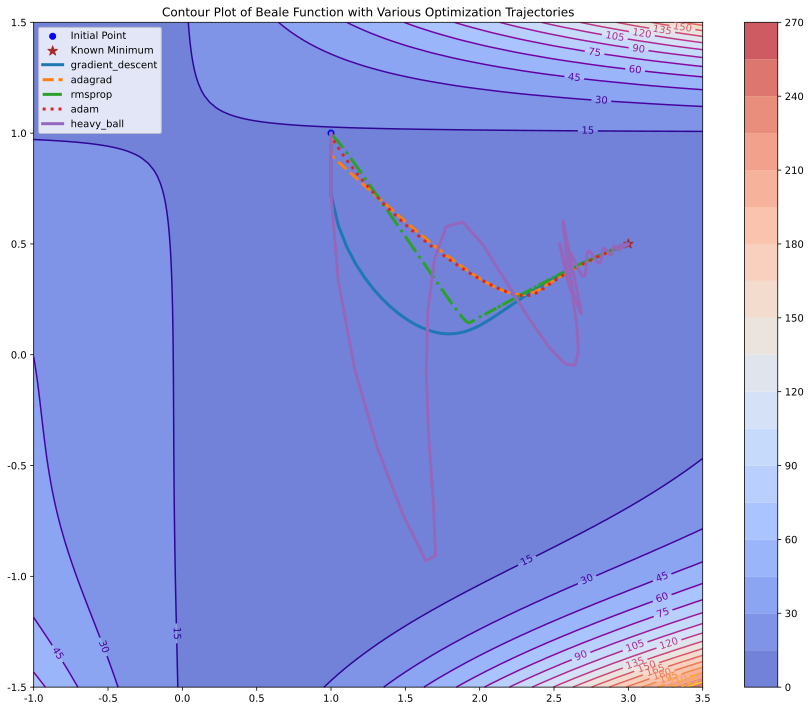

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Iterations')

Text(0, 0.5, 'Objective Value')

Text(0.5, 1.0, 'Objective Value vs. Iterations for Different Methods')

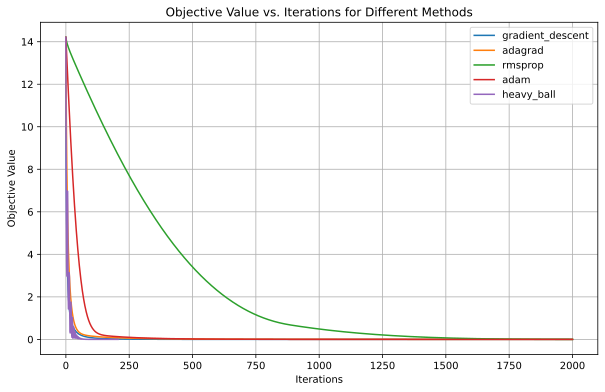

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Iterations')

Text(0, 0.5, 'Gradient Norm')

Text(0.5, 1.0, 'Gradient Norm vs. Iterations for Different Methods')

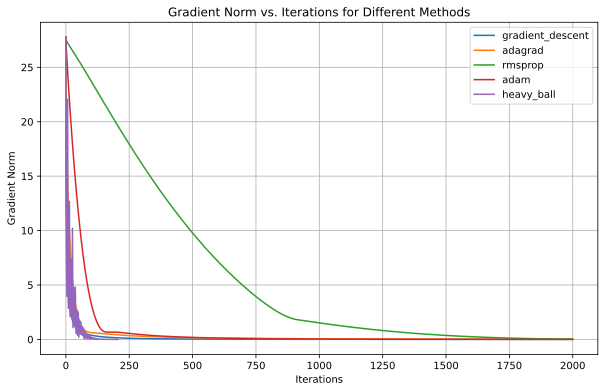

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-2,
    "adagrad": 1e-1,
    "rmsprop": 1e-3,
    "adam": 1e-2,
    "heavy_ball": 1e-2
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=2000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"

plt.figure(figsize=(15, 12))
plt.title('Contour Plot of Beale Function with Various Optimization Trajectories')
x1_con = np.linspace(-1, 3.5, 100)
x2_con = np.linspace(-1.5, 1.5, 100)
x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
y_con = beale_function([x1_mes, x2_mes])

# Plot contour


# Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm', 'cividis', 'inferno', 'magma', 'turbo', etc.)


cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
plt.colorbar(cset)
C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
plt.clabel(C, inline=True, fontsize=10)
plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

# Plot trajectories for each method
styles = ['-', '--', '-.', ':', '-', '--']
widths = [3, 3, 3, 3, 3, 3, 3]
for method, style, width in zip(methods, styles, widths):
    traj = results[method]['trajectory']
    x_path, y_path = traj[:, 0], traj[:, 1]
    plt.plot(x_path, y_path, label=f'{method}', linestyle=style, linewidth = width)

plt.legend(loc='upper left')
plt.show()



# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

### Let's plot these algorithms with different stepsizes

We plot the trajectories of the same algorithm with different stepsizes. Let's start from gradient descent.

In [ ]:
results = {}

# Define learning rates for gradient descent
learning_rates = [1e-4, 5e-3, 1e-3, 1e-2, 4e-2]
method = "gradient_descent"  # Specify the method

# Run optimization for each learning rate
for eta in learning_rates:
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")

    # Store the results
    results[eta] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]

for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [4, 2, 2, 2, 2, 4 ]
    for eta, style, marker, width in zip(learning_rates, styles, markers, widths):
        traj = results[eta]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method} (eta={eta})', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['objective'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title(f'Objective Value vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['gradient_norm'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norm vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
results = {}

# Define learning rates for gradient descent
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
method = "heavy_ball"  # Specify the method

# Run optimization for each learning rate
for eta in learning_rates:
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")

    # Store the results
    results[eta] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [4, 2, 2, 2, 2, 4 ]
    for eta, style, marker, width in zip(learning_rates, styles, markers, widths):
        traj = results[eta]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method} (eta={eta})', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['objective'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title(f'Objective Value vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['gradient_norm'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norm vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
results = {}

# Define learning rates for gradient descent
learning_rates = [1e-3, 1e-2, 5e-2, 1e-1, 5e-1]
method = "adagrad"  # Specify the method

# Run optimization for each learning rate
for eta in learning_rates:
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")

    # Store the results
    results[eta] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [4, 2, 2, 2, 2, 4 ]
    for eta, style, marker, width in zip(learning_rates, styles, markers, widths):
        traj = results[eta]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method} (eta={eta})', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['objective'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title(f'Objective Value vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['gradient_norm'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norm vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
results = {}

# Define learning rates for gradient descent
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
method = "adam"  # Specify the method

# Run optimization for each learning rate
for eta in learning_rates:
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")

    # Store the results
    results[eta] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [4, 2, 2, 2, 2, 4 ]
    for eta, style, marker, width in zip(learning_rates, styles, markers, widths):
        traj = results[eta]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method} (eta={eta})', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['objective'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title(f'Objective Value vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['gradient_norm'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norm vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
results = {}

# Define learning rates for gradient descent
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
method = "rmsprop"  # Specify the method

# Run optimization for each learning rate
for eta in learning_rates:
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")

    # Store the results
    results[eta] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [4, 2, 2, 2, 2, 4 ]
    for eta, style, marker, width in zip(learning_rates, styles, markers, widths):
        traj = results[eta]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method} (eta={eta})', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['objective'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title(f'Objective Value vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different learning rates
plt.figure(figsize=(10, 6))
for eta, data in results.items():
    plt.plot(data['gradient_norm'], label=f'{method} (eta={eta})')
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title(f'Gradient Norm vs. Iterations for {method} with Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Let's now compare these methods with some fixed stepsizes. See the relative pace of these methods


We use a 0.01 stepsize for all of them.

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-3,
    "adagrad": 1e-3,
    "rmsprop": 1e-3,
    "adam": 1e-3,
    "heavy_ball": 1e-3
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3,3,3,3,3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-2,
    "adagrad": 1e-2,
    "rmsprop": 1e-2,
    "adam": 1e-2,
    "heavy_ball": 1e-2
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3, 3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Let's set a large learning rate for adagrad. Then it converges very fast.

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-2,
    "adagrad": 1,
    "rmsprop": 1e-2,
    "adam": 1e-2,
    "heavy_ball": 1e-2
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3, 3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# We randomly initialize these algorithms. If the $f(x^K) < 0.01$, we say the algorithm succeeds. Let's calculate the avarage success rate with randomized initialization.

gradient_descent method with learning rate 0.001, last iterate is [2.98112425 0.49524967], function value is 5.826541492742662e-05, success
gradient_descent method with learning rate 0.001, last iterate is [nan nan], function value is nan, failure
gradient_descent method with learning rate 0.001, last iterate is [-3.10895232  1.25420348], function value is 0.8828939872823968, failure
gradient_descent method with learning rate 0.001, last iterate is [2.98060263 0.49511728], function value is 6.156617247662848e-05, success
gradient_descent method with learning rate 0.001, last iterate is [2.98202311 0.49547765], function value is 5.279520180440572e-05, success
gradient_descent method with learning rate 0.001, last iterate is [2.98039891 0.49506556], function value is 6.288046750550915e-05, success
gradient_descent method with learning rate 0.001, last iterate is [-3.11351155  1.25389897], function value is 0.8823450265689629, failure
gradient_descent method with learning rate 0.001, last

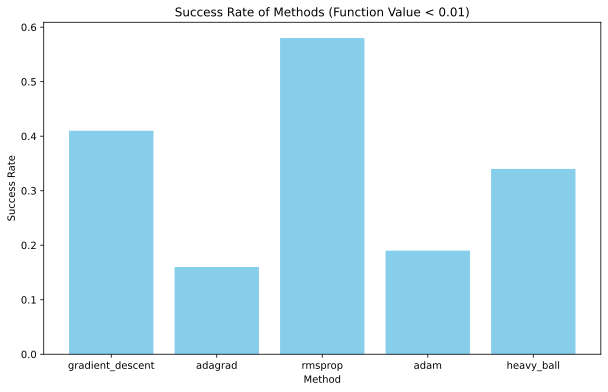

For algorithm gradient_descent with learning rate 0.001, the success rate is 0.41, the average function value of the last iterate is 0.2462.
For algorithm adagrad with learning rate 0.04, the success rate is 0.16, the average function value of the last iterate is 53.2249.
For algorithm rmsprop with learning rate 0.001, the success rate is 0.58, the average function value of the last iterate is 1.2323.
For algorithm adam with learning rate 0.001, the success rate is 0.19, the average function value of the last iterate is 7.1349.
For algorithm heavy_ball with learning rate 0.001, the success rate is 0.34, the average function value of the last iterate is 0.1883.


In [ ]:

methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-3,
    "adagrad": 4e-2,
    "rmsprop": 1e-3,
    "adam": 1e-3,
    "heavy_ball": 1e-3
}

success_threshold = 0.01
N = 100

# Adjust the experiment to treat NaN values as failures and print detailed messages per iteration

# Track results for each method
success_rate = {}
average_function_value = {}

# Repeat the experiment for each method
for method in methods:
    success_count = 0
    function_values = []

    for _ in range(N):
        # Random initialization in the range [-10, 10]
        x_init = np.random.uniform(-5, 5, 2)
        eta = learning_rates[method]

        final_point, traj, obj, grad_norm = unconstrained_optimization(
            beale_function, beale_gradient, None, learning_rate=eta,
            num_iterations=10000, method=method, x_init=x_init, check_convergence=False
        )
        final_value = obj[-1]
        function_values.append(final_value)

        if np.isnan(final_value) or final_value >= success_threshold:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, failure")
        else:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, success")
            success_count += 1

    # Calculate success rate and average function value
    success_rate[method] = success_count / N
    valid_function_values = [v for v in function_values if not np.isnan(v)]
    average_function_value[method] = np.mean(valid_function_values) if valid_function_values else float('nan')

# Print final summary messages
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


# Plotting the bar plot for success rate
plt.figure(figsize=(10, 6))
plt.bar(success_rate.keys(), success_rate.values(), color='skyblue')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.title('Success Rate of Methods (Function Value < 0.01)')
plt.show()



# Print detailed messages for each method
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


## Let's try using line search

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-1,
    "adagrad": 1,
    "rmsprop": 1e-1,
    "adam": 1e-1,
    "heavy_ball": 1e-1
}

# Run optimization for each method with line search
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        beale_function, beale_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([1.0, 1.0]),check_convergence=False, line_search=True
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate line search stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }

# Set up the contour plot of the Beale function
plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-1, 3.5, 100)
    x2_con = np.linspace(-1.5, 1.5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = beale_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(1, 1, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(3, 0.5, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each method
    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()

# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## As we can see below, line search significantly increases the success rate

gradient_descent method with learning rate 0.1, last iterate is [-2.96337476  1.26400999], function value is 0.9012136719915329, failure
gradient_descent method with learning rate 0.1, last iterate is [ 0.08181056 -2.85293745], function value is 9.849728846013923, failure
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 1.6092777567837193e-19, success
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 7.722860747857033e-26, success
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 1.6685394221555926e-24, success
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 1.1960413838419105e-24, success
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 1.1168134361324488e-24, success
gradient_descent method with learning rate 0.1, last iterate is [3.  0.5], function value is 1.17201391

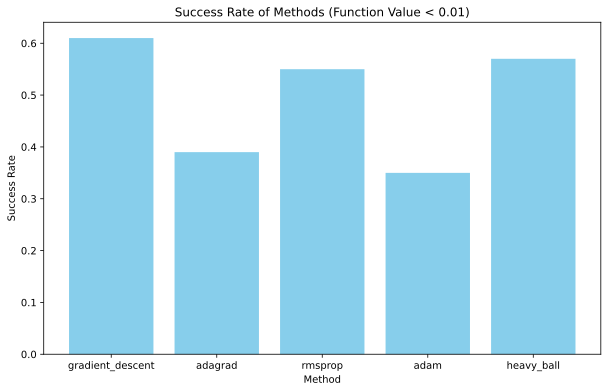

For algorithm gradient_descent with learning rate 0.1, the success rate is 0.61, the average function value of the last iterate is 0.8272.
For algorithm adagrad with learning rate 1, the success rate is 0.39, the average function value of the last iterate is 2.9961.
For algorithm rmsprop with learning rate 0.1, the success rate is 0.55, the average function value of the last iterate is 0.9334.
For algorithm adam with learning rate 0.1, the success rate is 0.35, the average function value of the last iterate is 1.9596.
For algorithm heavy_ball with learning rate 0.1, the success rate is 0.57, the average function value of the last iterate is 1.1572.


In [ ]:
success_rate = {}
average_function_value = {}
success_threshold = 0.01
N = 100

# Repeat the experiment for each method
for method in methods:
    success_count = 0
    function_values = []

    for _ in range(N):
        # Random initialization in the range [-10, 10]
        x_init = np.random.uniform(-5, 5, 2)
        eta = learning_rates[method]

        final_point, traj, obj, grad_norm = unconstrained_optimization(
            beale_function, beale_gradient, None, learning_rate=eta,
            num_iterations=2000, method=method, x_init=x_init, check_convergence=False, line_search=True
        )
        final_value = obj[-1]
        function_values.append(final_value)

        if np.isnan(final_value) or final_value >= success_threshold:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, failure")
        else:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, success")
            success_count += 1

    # Calculate success rate and average function value
    success_rate[method] = success_count / N
    valid_function_values = [v for v in function_values if not np.isnan(v)]
    average_function_value[method] = np.mean(valid_function_values) if valid_function_values else float('nan')

# Print final summary messages
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


# Plotting the bar plot for success rate
plt.figure(figsize=(10, 6))
plt.bar(success_rate.keys(), success_rate.values(), color='skyblue')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.title('Success Rate of Methods (Function Value < 0.01)')
plt.show()



# Print detailed messages for each method
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


## Rosenbrock Function

The Rosenbrock function $f(x, y) = (a - x)^2 + b(y - x^2)^2$ (with $a=1$, $b=100$) has a global minimum at $(1,1)$ inside a narrow, curved valley. The banana-shaped valley makes it particularly challenging: algorithms quickly reach the valley floor but then struggle to navigate along the flat, curved bottom toward the minimizer. This tests how well each optimizer handles ill-conditioned curvature.

In [ ]:

def rosenbrock_function(x, a=1, b=100):
    """
    Rosenbrock function.

    Parameters:
    - x: A 2D numpy array [x1, x2].
    - a: The constant a in the Rosenbrock function (default is 1).
    - b: The constant b in the Rosenbrock function (default is 100).

    Returns:
    - The value of the Rosenbrock function at (x1, x2).
    """
    x1, x2 = x
    return (a - x1)**2 + b * (x2 - x1**2)**2

def rosenbrock_gradient(x, a=1, b=100):
    """
    Gradient of the Rosenbrock function.

    Parameters:
    - x: A 2D numpy array [x1, x2].
    - a: The constant a in the Rosenbrock function (default is 1).
    - b: The constant b in the Rosenbrock function (default is 100).

    Returns:
    - A numpy array containing the gradient [df/dx1, df/dx2] at (x1, x2).
    """
    x1, x2 = x
    df_dx1 = -2 * (a - x1) - 4 * b * x1 * (x2 - x1**2)
    df_dx2 = 2 * b * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the Rosenbrock function
def rosenbrock_function(x, a=1, b=100):
    x1, x2 = x
    return (a - x1)**2 + b * (x2 - x1**2)**2

# Generate a grid of x1 and x2 values
x1_range = np.linspace(-2, 2, 400)
x2_range = np.linspace(-1, 3, 400)
x1, x2 = np.meshgrid(x1_range, x2_range)
z = rosenbrock_function([x1, x2])

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1, x2, z, cmap='viridis', edgecolor='none', alpha=0.8)

# Customize the plot
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_title('Surface Plot of the Rosenbrock Function')

# Show the plot
plt.show()



Output hidden; open in https://colab.research.google.com to view.

#### Let's try these methods with different stepsizes. Whether they can find the optimal solution depends on the initialization and stepsizes.

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-3,
    "adagrad": 1,
    "rmsprop": 4e-3,
    "adam": 4e-1,
    "heavy_ball": 1e-3
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        rosenbrock_function, rosenbrock_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([-2.0,1.5])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-5, 5, 100)
    x2_con = np.linspace(-5, 5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = rosenbrock_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(-2, 1.5, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(1, 1, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3, 3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-3,
    "adagrad": 5e-1,
    "rmsprop": 4e-1,
    "adam": 4e-2,
    "heavy_ball": 4e-4
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        rosenbrock_function, rosenbrock_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([-2.0,1.5])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-5, 5, 100)
    x2_con = np.linspace(-5, 5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = rosenbrock_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(-2, 1.5, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(1, 1, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3, 3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Change to a different initialization



In [ ]:
# Set up methods and learning rates
results = {}
methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-3,
    "adagrad": 1,
    "rmsprop": 4e-3,
    "adam": 4e-1,
    "heavy_ball": 1e-3
}

# Run optimization for each method
for method in methods:
    eta = learning_rates[method]
    final_point, traj, obj, grad_norm = unconstrained_optimization(
        rosenbrock_function, rosenbrock_gradient, None, learning_rate=eta,
        num_iterations=5000, method=method, x_init=np.array([-2.0,2])
    )
    num_iterations = len(traj) - 1
    func_value = obj[-1]
    gradient = grad_norm[-1]
    print(f"Method {method} with learning rate {eta} stops after {num_iterations} iterations,")
    print(f"the last iterate is {final_point}, its function value is {func_value:.4f}, gradient norm is {gradient:.4f}\n")
    # Store the results
    results[method] = {
        'trajectory': traj,
        'objective': obj,
        'gradient_norm': grad_norm
    }


# Set up the contour plot of the Beale function
InteractiveShell.ast_node_interactivity = "last"


plot_steps = [50, 100, 1000, 5000]
for number_steps_plotted in plot_steps:
    plt.figure(figsize=(15, 12))
    plt.title(f'{method} Trajectories with {number_steps_plotted} steps')
    x1_con = np.linspace(-5, 5, 100)
    x2_con = np.linspace(-5, 5, 100)
    x1_mes, x2_mes = np.meshgrid(x1_con, x2_con)
    y_con = rosenbrock_function([x1_mes, x2_mes])

    # Plot contour
    cset = plt.contourf(x1_mes, x2_mes, y_con, levels=20, alpha=.75, cmap='coolwarm')
    plt.colorbar(cset)
    C = plt.contour(x1_mes, x2_mes, y_con, levels=20, cmap='plasma')
    plt.clabel(C, inline=True, fontsize=10)
    plt.scatter(-2, 1.5, marker="8", color="b", s=40, label="Initial Point")  # Initial point
    plt.scatter(1, 1, marker="*", color="brown", s=100, label="Known Minimum")  # Known minimum

    # Plot trajectories for each learning rate

    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]
    markers = ['o', '^', 's', 'x', '*']
    widths = [3, 3, 3, 3, 3, 3 ]
    for method, style, marker, width in zip(methods, styles, markers, widths):
        traj = results[method]['trajectory']
        x_path, y_path = traj[:number_steps_plotted, 0], traj[:number_steps_plotted , 1]
        plt.plot(x_path, y_path, label=f'{method}', linestyle=style, marker=marker, linewidth=width)

    plt.legend(loc='upper left')
    plt.show()


# Plotting the objectives for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['objective'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Objective Value')
plt.title('Objective Value vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the gradient norms for different methods
plt.figure(figsize=(10, 6))
for method, data in results.items():
    plt.plot(data['gradient_norm'], label=method)
plt.xlabel('Iterations')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs. Iterations for Different Methods')
plt.legend()
plt.grid(True)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# We randomly initialize these algorithms. If the $f(x^K) < 0.01$, we say the algorithm succeeds. Let's calculate the avarage success rate with randomized initialization.

gradient_descent method with learning rate 0.0001, last iterate is [0.50014671 0.24764114], function value is 0.25048110600765644, failure
gradient_descent method with learning rate 0.0001, last iterate is [1.5785319  2.49342846], function value is 0.33497654895304396, failure
gradient_descent method with learning rate 0.0001, last iterate is [-1.56858623  2.46789495], function value is 6.603158973812108, failure
gradient_descent method with learning rate 0.0001, last iterate is [-0.66406263  0.44897825], function value is 2.7755029457314544, failure
gradient_descent method with learning rate 0.0001, last iterate is [0.56594987 0.31814099], function value is 0.1888653260399538, failure
gradient_descent method with learning rate 0.0001, last iterate is [-1.34670108  1.82126067], function value is 5.512868729062557, failure
gradient_descent method with learning rate 0.0001, last iterate is [1.06098398 1.12592225], function value is 0.003724579811184636, success
gradient_descent method wi

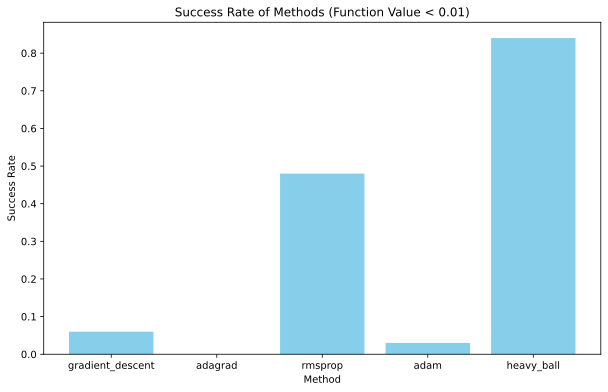

For algorithm gradient_descent with learning rate 0.0001, the success rate is 0.06, the average function value of the last iterate is 1.1825.
For algorithm adagrad with learning rate 0.0004, the success rate is 0.00, the average function value of the last iterate is 8897.2711.
For algorithm rmsprop with learning rate 0.0004, the success rate is 0.48, the average function value of the last iterate is 4.8736.
For algorithm adam with learning rate 0.0005, the success rate is 0.03, the average function value of the last iterate is 20.0757.
For algorithm heavy_ball with learning rate 0.0001, the success rate is 0.84, the average function value of the last iterate is 0.0148.


In [ ]:

methods = ["gradient_descent", "adagrad", "rmsprop", "adam", "heavy_ball"]
learning_rates = {
    "gradient_descent": 1e-4,
    "adagrad": 4e-4,
    "rmsprop": 4e-4,
    "adam": 5e-4,
    "heavy_ball": 1e-4
}

success_threshold = 0.01
N = 100

# Adjust the experiment to treat NaN values as failures and print detailed messages per iteration

# Track results for each method
success_rate = {}
average_function_value = {}

# Repeat the experiment for each method
for method in methods:
    success_count = 0
    function_values = []

    for _ in range(N):
        # Random initialization in the range [-10, 10]
        x_init = np.random.uniform(-5, 5, 2)
        eta = learning_rates[method]

        final_point, traj, obj, grad_norm = unconstrained_optimization(
            rosenbrock_function, rosenbrock_gradient, None, learning_rate=eta,
            num_iterations=10000, method=method, x_init=x_init, check_convergence=False
        )
        final_value = obj[-1]
        function_values.append(final_value)

        if np.isnan(final_value) or final_value >= success_threshold:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, failure")
        else:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, success")
            success_count += 1

    # Calculate success rate and average function value
    success_rate[method] = success_count / N
    valid_function_values = [v for v in function_values if not np.isnan(v)]
    average_function_value[method] = np.mean(valid_function_values) if valid_function_values else float('nan')

# Print final summary messages
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


# Plotting the bar plot for success rate
plt.figure(figsize=(10, 6))
plt.bar(success_rate.keys(), success_rate.values(), color='skyblue')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.title('Success Rate of Methods (Function Value < 0.01)')
plt.show()



# Print detailed messages for each method
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


gradient_descent method with learning rate 0.1, last iterate is [0.96157933 0.9243954 ], function value is 0.001481879505580124, success
gradient_descent method with learning rate 0.1, last iterate is [0.96472031 0.93065062], function value is 0.0012447765222955414, success
gradient_descent method with learning rate 0.1, last iterate is [0.96482309 0.93081315], function value is 0.0012379114139317408, success
gradient_descent method with learning rate 0.1, last iterate is [0.96387259 0.92899393], function value is 0.0013055083150422912, success
gradient_descent method with learning rate 0.1, last iterate is [0.96373962 0.92872894], function value is 0.0013152391216496079, success
gradient_descent method with learning rate 0.1, last iterate is [0.96337878 0.92804391], function value is 0.0013414135391544462, success
gradient_descent method with learning rate 0.1, last iterate is [0.95812352 0.91793104], function value is 0.0017541245016994033, success
gradient_descent method with learni

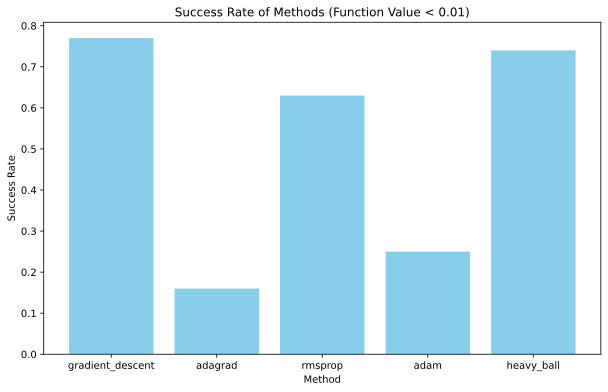

For algorithm gradient_descent with learning rate 0.1, the success rate is 0.77, the average function value of the last iterate is 0.1733.
For algorithm adagrad with learning rate 1, the success rate is 0.16, the average function value of the last iterate is 1.6574.
For algorithm rmsprop with learning rate 0.1, the success rate is 0.63, the average function value of the last iterate is 0.9728.
For algorithm adam with learning rate 0.1, the success rate is 0.25, the average function value of the last iterate is 1.5698.
For algorithm heavy_ball with learning rate 0.1, the success rate is 0.74, the average function value of the last iterate is 0.4163.


In [ ]:
success_rate = {}
average_function_value = {}
success_threshold = 0.01
N = 100

# Repeat the experiment for each method
for method in methods:
    success_count = 0
    function_values = []

    for _ in range(N):
        # Random initialization in the range [-10, 10]
        x_init = np.random.uniform(-5, 5, 2)
        eta = learning_rates[method]

        final_point, traj, obj, grad_norm = unconstrained_optimization(
            rosenbrock_function, rosenbrock_gradient, None, learning_rate=eta,
            num_iterations=2000, method=method, x_init=x_init, check_convergence=False, line_search=True
        )
        final_value = obj[-1]
        function_values.append(final_value)

        if np.isnan(final_value) or final_value >= success_threshold:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, failure")
        else:
            print(f"{method} method with learning rate {eta}, last iterate is {final_point}, "
                  f"function value is {final_value}, success")
            success_count += 1

    # Calculate success rate and average function value
    success_rate[method] = success_count / N
    valid_function_values = [v for v in function_values if not np.isnan(v)]
    average_function_value[method] = np.mean(valid_function_values) if valid_function_values else float('nan')

# Print final summary messages
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


# Plotting the bar plot for success rate
plt.figure(figsize=(10, 6))
plt.bar(success_rate.keys(), success_rate.values(), color='skyblue')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.title('Success Rate of Methods (Function Value < 0.01)')
plt.show()



# Print detailed messages for each method
for method in methods:
    eta = learning_rates[method]
    success = success_rate[method]
    avg_value = average_function_value[method]

    if np.isnan(avg_value):
        avg_value_message = "NaN (numerical issues encountered)"
    else:
        avg_value_message = f"{avg_value:.4f}"

    print(f"For algorithm {method} with learning rate {eta}, the success rate is {success:.2f}, "
          f"the average function value of the last iterate is {avg_value_message}.")


## Summary

Key observations from the experiments above:

- **Gradient descent** with a fixed step size is a reliable baseline but sensitive to the learning rate and problem conditioning.
- **Heavy ball (momentum)** can converge faster by accumulating velocity, but overshoots easily on non-convex functions if the momentum parameter is too large.
- **Adagrad** adapts per-coordinate step sizes and can tolerate large initial learning rates; however, its monotonically growing denominator may slow it down over many iterations.
- **RMSProp** fixes Adagrad's issue by using an exponential moving average of squared gradients, keeping the effective learning rate from decaying to zero.
- **Adam** combines momentum with adaptive learning rates and is generally the most robust default across different problems and initializations.
- **Backtracking line search** substantially improves the success rate of all methods by automatically selecting an appropriate step size at each iteration, at the cost of additional function evaluations.
- **When to use each:** Adam is a strong default for most problems. Adagrad excels with sparse gradients. RMSProp is popular in reinforcement learning. SGD with momentum remains competitive for well-tuned deep learning training.